# PHASE 2 - END OF PHASE PROJECT

## Lights, Camera, Investment: Unlocking Profitability in the Movie Industry

#### Group Members: Caroline Wachira, Elvis Kiprono, Janine Makorre, Naomi Ngigi, Godwine Wasonga

#### Class: DSF-12 FT

#### April 2025

#### Moringa School


### Introduction

Making a film is a creative endeavour, but it's also a business project. Just like any other business, most films are intended to make money.
The film industry is one of the most intriguing and evolving sectors, shaping how stories are told and consumed globally. As stakeholders tap into the visual storytelling landscape, they adapt to the ever-changing demands and opportunities presented by the global movie industry
There are three pillars of the movie business: 
1. Production - the stage where the film is made
2. Distribution - making a film available to an audience
3. Exhibition - the public screening of the movie or the film's release in theaters

We will explore the movie industry with a bias on rating and Return on Investment(ROI) for the genres of film using historical data.

### Problem Statement

The movie industry is arguably one of the biggest entertainment sectors characterized by high financial stakes, significant risks, and unpredictable returns. Movies may fail to generate a profit due to poor planning, misaligned audience preferences, or ineffective marketing strategies. Investors and production companies face the challenge of identifying which factors contribute most to a movie's financial success and critical reception.

Decisions about funding, production, and marketing are made on the basis of intuition, experience, or scant data analysis. However, with the increasing pool of datasets that contain information on ratings of films, budgets, box office grossing, genre, release dates, and audience demographics, there is an opportunity to leverage data-driven insights in order to minimize risk and optimize returns on investment (ROI).

The primary problem this project seeks to address is the lack of a systematic approach to understanding the relationship between movie ratings (audience and critic reviews) and financial performance (ROI).Through analysis of previous film ratings, budgets, and revenues data, this project aims to provide investors and producers with useful insights. The overall aim is to create a system that can allow stakeholders to make sensible decisions about which projects to greenlight, how to best utilize resources, and how to maximize ROI while keeping risks to a minimum in an increasingly competitive and dynamic market.

This analysis will not only be useful to investors but also help in a better understanding of audience behavior, allowing for the production of content that appeals to viewers and fuels sustainable growth in the entertainment industry.

### Objectives:

1. What genre is most popular among viewers based on ratings?

2. When is the best time to release a movie to maximize viewership and revenue?

3. What budget range yields the highest return on investment (ROI)?

### Description of Dataset

Our datasets are are obtained from Box Office Mojo, IMDB, Rotten Tomatoes, TheMovieDB, and The Numbers and contains information about movie genres, ratings, release dates, budgets and revenues. It contains 5 datasets and consists of several columns and tables describing factors influencing movie success. 


### Project Approach

The goal of this project is to analyze the relationship between movie ratings, financial performance, and other key factors to provide actionable insights for stakeholders in the film industry.

### 2.0. Importing Relevant libraries for data analysis.

In [1]:
import itertools
import statsmodels.api as sm
import numpy as np
import pandas as pd 
from numbers import Number
import sqlite3
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import f_oneway

import pickle
from fractions import Fraction


### 2.1.  Loading The Data 

In [2]:
bom_df = pd.read_csv('zippedData/bom.movie_gross.csv/bom.movie_gross.csv')
bom_df

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


In [3]:
rt_df = pd.read_csv('zippedData/rt.movie_info.tsv.gz', delimiter = '\t')
rt_df

,id,synopsis,rating,genre,director,writer,theater_date,dvd_date,currency,box_office,runtime,studio
0,1,"This gritty, fast-paced, and innovative police...",R,Action and Adventure|Classics|Drama,William Friedkin,Ernest Tidyman,"Oct 9, 1971","Sep 25, 2001",NaN,NaN,104 minutes,NaN
1,3,"New York City, not-too-distant-future: Eric Pa...",R,Drama|Science Fiction and Fantasy,David Cronenberg,David Cronenberg|Don DeLillo,"Aug 17, 2012","Jan 1, 2013",$,"600,000",108 minutes,Entertainment One
2,5,Illeana Douglas delivers a superb performance ...,R,Drama|Musical and Performing Arts,Allison Anders,Allison Anders,"Sep 13, 1996","Apr 18, 2000",NaN,NaN,116 minutes,NaN
3,6,Michael Douglas runs afoul of a treacherous su...,R,Drama|Mystery and Suspense,Barry Levinson,Paul Attanasio|Michael Crichton,"Dec 9, 1994","Aug 27, 1997",NaN,NaN,128 minutes,NaN
4,7,NaN,NR,Drama|Romance,Rodney Bennett,Giles Cooper,NaN,NaN,NaN,NaN,200 minutes,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1555,1996,Forget terrorists or hijackers -- there's a ha...,R,Action and Adventure|Horror|Mystery and Suspense,NaN,NaN,"Aug 18, 2006","Jan 2, 2007",$,"33,886,034",106 minutes,New Line Cinema
1556,1997,The popular Saturday Night Live sketch was exp...,PG,Comedy|Science Fiction and Fantasy,Steve Barron,Terry Turner|Tom Davis|Dan Aykroyd|Bonnie Turner,"Jul 23, 1993","Apr 17, 2001",NaN,NaN,88 minutes,Paramount Vantage
1557,1998,"Based on a novel by Richard Powell, when the l...",G,Classics|Comedy|Drama|Musical and Performing Arts,Gordon Douglas,NaN,"Jan 1, 1962","May 11, 2004",NaN,NaN,111 minutes,NaN
1558,1999,The Sandlot is a coming-of-age story about a g...,PG,Comedy|Drama|Kids and Family|Sports and Fitness,David Mickey Evans,David Mickey Evans|Robert Gunter,"Apr 1, 1993","Jan 29, 2002",NaN,NaN,101 minutes,NaN


In [4]:
rt_reviews_df = pd.read_csv('zippedData/rt.reviews.tsv/rt.reviews.tsv', delimiter = '\t', encoding = 'ISO-8859-1')
rt_reviews_df

,id,review,rating,fresh,critic,top_critic,publisher,date
0,3,A distinctly gallows take on contemporary fina...,3/5,fresh,PJ Nabarro,0,Patrick Nabarro,"November 10, 2018"
1,3,It's an allegory in search of a meaning that n...,NaN,rotten,Annalee Newitz,0,io9.com,"May 23, 2018"
2,3,... life lived in a bubble in financial dealin...,NaN,fresh,Sean Axmaker,0,Stream on Demand,"January 4, 2018"
3,3,Continuing along a line introduced in last yea...,NaN,fresh,Daniel Kasman,0,MUBI,"November 16, 2017"
4,3,... a perverse twist on neorealism...,NaN,fresh,NaN,0,Cinema Scope,"October 12, 2017"
...,...,...,...,...,...,...,...,...
54427,2000,The real charm of this trifle is the deadpan c...,NaN,fresh,Laura Sinagra,1,Village Voice,"September 24, 2002"
54428,2000,NaN,1/5,rotten,Michael Szymanski,0,Zap2it.com,"September 21, 2005"
54429,2000,NaN,2/5,rotten,Emanuel Levy,0,EmanuelLevy.Com,"July 17, 2005"
54430,2000,NaN,2.5/5,rotten,Christopher Null,0,Filmcritic.com,"September 7, 2003"


In [5]:
tmdb_df = pd.read_csv('zippedData/tmdb.movies.csv/tmdb.movies.csv')
tmdb_df

,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186
...,...,...,...,...,...,...,...,...,...,...
26512,26512,"[27, 18]",488143,en,Laboratory Conditions,0.600,2018-10-13,Laboratory Conditions,0.0,1
26513,26513,"[18, 53]",485975,en,_EXHIBIT_84xxx_,0.600,2018-05-01,_EXHIBIT_84xxx_,0.0,1
26514,26514,"[14, 28, 12]",381231,en,The Last One,0.600,2018-10-01,The Last One,0.0,1
26515,26515,"[10751, 12, 28]",366854,en,Trailer Made,0.600,2018-06-22,Trailer Made,0.0,1


In [6]:
tn_movie_df = pd.read_csv('zippedData/tn.movie_budgets.csv/tn.movie_budgets.csv')
tn_movie_df

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


In [7]:
conn = sqlite3.connect('zippedData/im.db/im.db')
im_df = pd.read_sql("""SELECT* FROM sqlite_master WHERE type='table';""",conn)
im_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


In [8]:
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';")
tables = cursor.fetchall()

# Step 2: Build the dictionary
db_schema = {}

for table_name in tables:
    table = table_name[0]
    cursor.execute(f"PRAGMA table_info({table});")
    columns = cursor.fetchall()
    column_names = [col[1] for col in columns]  # col[1] is the column name
    db_schema[table] = column_names


# Output example
print(db_schema)

{'movie_basics': ['movie_id', 'primary_title', 'original_title', 'start_year', 'runtime_minutes', 'genres'], 'directors': ['movie_id', 'person_id'], 'known_for': ['person_id', 'movie_id'], 'movie_akas': ['movie_id', 'ordering', 'title', 'region', 'language', 'types', 'attributes', 'is_original_title'], 'movie_ratings': ['movie_id', 'averagerating', 'numvotes'], 'persons': ['person_id', 'primary_name', 'birth_year', 'death_year', 'primary_profession'], 'principals': ['movie_id', 'ordering', 'person_id', 'category', 'job', 'characters'], 'writers': ['movie_id', 'person_id']}


## Querying Tables

In [9]:
pd.read_sql("SELECT * FROM movie_ratings", conn)

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21
...,...,...,...
73851,tt9805820,8.1,25
73852,tt9844256,7.5,24
73853,tt9851050,4.7,14
73854,tt9886934,7.0,5


In [10]:
pd.read_sql("SELECT * FROM movie_basics", conn)

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"
...,...,...,...,...,...,...
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None


### 3.0. Data Preparation and Cleaning

The datasets provided above have a few irrelevant features that require appropriate handling for conclusion of a smooth analysis and inculcate accuracy and efficiency in reaching the final recommendation.
 
The steps involved in this process include: dropping/replacing missing values, handling duplicates in the data, formatting data inconsistencies and formatting Datatypes.

We need to convert the fractional ratings into decimal form to standardize the data and make it easier to work with in subsequent analyses, such as calculating averages or performing statistical tests.

In [11]:
# Convert fractions to decimals
def fraction_to_float(fraction_str):
    try:
        return float(Fraction(fraction_str))
    except (ValueError, TypeError):
        return fraction_str
    
rt_reviews_df['rating'] = rt_reviews_df['rating'].apply(fraction_to_float)
rt_reviews_df

,id,review,rating,fresh,critic,top_critic,publisher,date
0,3,A distinctly gallows take on contemporary fina...,0.6,fresh,PJ Nabarro,0,Patrick Nabarro,"November 10, 2018"
1,3,It's an allegory in search of a meaning that n...,NaN,rotten,Annalee Newitz,0,io9.com,"May 23, 2018"
2,3,... life lived in a bubble in financial dealin...,NaN,fresh,Sean Axmaker,0,Stream on Demand,"January 4, 2018"
3,3,Continuing along a line introduced in last yea...,NaN,fresh,Daniel Kasman,0,MUBI,"November 16, 2017"
4,3,... a perverse twist on neorealism...,NaN,fresh,NaN,0,Cinema Scope,"October 12, 2017"
...,...,...,...,...,...,...,...,...
54427,2000,The real charm of this trifle is the deadpan c...,NaN,fresh,Laura Sinagra,1,Village Voice,"September 24, 2002"
54428,2000,NaN,0.2,rotten,Michael Szymanski,0,Zap2it.com,"September 21, 2005"
54429,2000,NaN,0.4,rotten,Emanuel Levy,0,EmanuelLevy.Com,"July 17, 2005"
54430,2000,NaN,2.5/5,rotten,Christopher Null,0,Filmcritic.com,"September 7, 2003"


We were also focused on cleaning specific columns within the tn_movie_df DataFrame that contained financial data represented as strings with dollar signs. The columns targeted for cleaning were 'production_budget', 'domestic_gross', and 'worldwide_gross'. Our approach involved removing the dollar signs and converting the remaining string values to a float data type.

In [12]:
cols_to_clean = ['production_budget', 'domestic_gross', 'worldwide_gross']

for col in cols_to_clean:
    tn_movie_df[col] = tn_movie_df[col].replace('[\$,]', '', regex=True).astype(float)


We converted the 'domestic_gross', 'foreign_gross', 'production_budget', and 'worldwide_gross' columns to numeric types, this ensures the integrity of our dataset for subsequent analysis. This step is crucial for preparing the data for accurate calculations, such as determining financial performance metrics like return on investment (ROI) for movies.

In [13]:
# Convert 'domestic_gross' and 'foreign_gross' to numeric in bom_df
bom_df['domestic_gross'] = pd.to_numeric(bom_df['domestic_gross'], errors='coerce')
bom_df['foreign_gross'] = pd.to_numeric(bom_df['foreign_gross'], errors='coerce')

# Convert 'domestic_gross' and 'foreign_gross' to numeric in tn_movie_df
tn_movie_df['domestic_gross'] = pd.to_numeric(tn_movie_df['domestic_gross'], errors='coerce')
tn_movie_df['production_budget']=pd.to_numeric(tn_movie_df['production_budget'], errors='coerce')
tn_movie_df['worldwide_gross']=pd.to_numeric(tn_movie_df['worldwide_gross'], errors='coerce')

We then proceeded to calculate the 'profit_gross' for each movie in the tn_movie_df DataFrame by subtracting the 'production_budget' from the 'worldwide_gross'.

In [14]:
tn_movie_df['profit_gross'] = tn_movie_df['worldwide_gross'] - tn_movie_df['production_budget']
tn_movie_df

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,profit_gross
0,1,"Dec 18, 2009",Avatar,425000000.0,760507625.0,2.776345e+09,2.351345e+09
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,6.350639e+08
2,3,"Jun 7, 2019",Dark Phoenix,350000000.0,42762350.0,1.497624e+08,-2.002376e+08
3,4,"May 1, 2015",Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1.072414e+09
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,9.997217e+08
...,...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,7000.0,0.0,0.000000e+00,-7.000000e+03
5778,79,"Apr 2, 1999",Following,6000.0,48482.0,2.404950e+05,2.344950e+05
5779,80,"Jul 13, 2005",Return to the Land of Wonders,5000.0,1338.0,1.338000e+03,-3.662000e+03
5780,81,"Sep 29, 2015",A Plague So Pleasant,1400.0,0.0,0.000000e+00,-1.400000e+03


In [15]:
tn_movie_df.rename(columns={'movie': 'title'}, inplace=True)
tn_movie_df.head()

,id,release_date,title,production_budget,domestic_gross,worldwide_gross,profit_gross
0,1,"Dec 18, 2009",Avatar,425000000.0,760507625.0,2.776345e+09,2.351345e+09
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,6.350639e+08
2,3,"Jun 7, 2019",Dark Phoenix,350000000.0,42762350.0,1.497624e+08,-2.002376e+08
3,4,"May 1, 2015",Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1.072414e+09
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,9.997217e+08


We converted the 'domestic_gross' and 'foreign_gross' columns to numeric, filling in any conversion errors with zeros, and then adding these columns together to calculate the 'worldwide_gross' for each entry in the `bom_df` DataFrame.

In [16]:
bom_df['domestic_gross'] = pd.to_numeric(bom_df['domestic_gross'], errors='coerce')
bom_df['foreign_gross'] = pd.to_numeric(bom_df['foreign_gross'], errors='coerce')
bom_df.fillna(0, inplace=True)
bom_df['worldwide_gross'] = bom_df['domestic_gross'] + bom_df['foreign_gross']

bom_df

,title,studio,domestic_gross,foreign_gross,year,worldwide_gross
0,Toy Story 3,BV,415000000.0,652000000.0,2010,1.067000e+09
1,Alice in Wonderland (2010),BV,334200000.0,691300000.0,2010,1.025500e+09
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010,9.603000e+08
3,Inception,WB,292600000.0,535700000.0,2010,8.283000e+08
4,Shrek Forever After,P/DW,238700000.0,513900000.0,2010,7.526000e+08
...,...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,0.0,2018,6.200000e+03
3383,Edward II (2018 re-release),FM,4800.0,0.0,2018,4.800000e+03
3384,El Pacto,Sony,2500.0,0.0,2018,2.500000e+03
3385,The Swan,Synergetic,2400.0,0.0,2018,2.400000e+03


## Data Visualization
We are using data visualization tools to  make it easier to see and understand patterns, trends, and outliers in our datasets.


#### genre that is most popular among viewers based on ratings

In [17]:
pd.read_sql('''SELECT genres, AVG(averagerating)  AS avg_rating
FROM movie_ratings
JOIN movie_basics USING (movie_id)
GROUP BY genres ORDER BY avg_rating DESC;''' , conn)


,genres,avg_rating
0,"Comedy,Documentary,Fantasy",9.4
1,"Documentary,Family,Musical",9.3
2,"History,Sport",9.2
3,"Music,Mystery",9.0
4,Game-Show,9.0
...,...,...
919,"Crime,Music",2.4
920,"History,Sci-Fi,Thriller",2.3
921,"Adventure,Crime,Romance",2.3
922,"Adult,Horror",2.0


In [18]:
genre_df=pd.read_sql('''SELECT genres, AVG(averagerating)  AS avg_rating
FROM movie_ratings
JOIN movie_basics USING (movie_id)
GROUP BY genres ORDER BY avg_rating DESC
LIMIT 20
;''' , conn)


In [19]:
genre_df

,genres,avg_rating
0,"Comedy,Documentary,Fantasy",9.40
1,"Documentary,Family,Musical",9.30
2,"History,Sport",9.20
3,"Music,Mystery",9.00
4,Game-Show,9.00
5,"Drama,Short",8.80
6,"Drama,Fantasy,War",8.80
7,"Documentary,News,Sport",8.80
8,"Documentary,News,Reality-TV",8.80
9,"Comedy,Drama,Reality-TV",8.80


In [20]:
genres = genre_df['genres'].tolist()
rating = genre_df['avg_rating'].tolist()

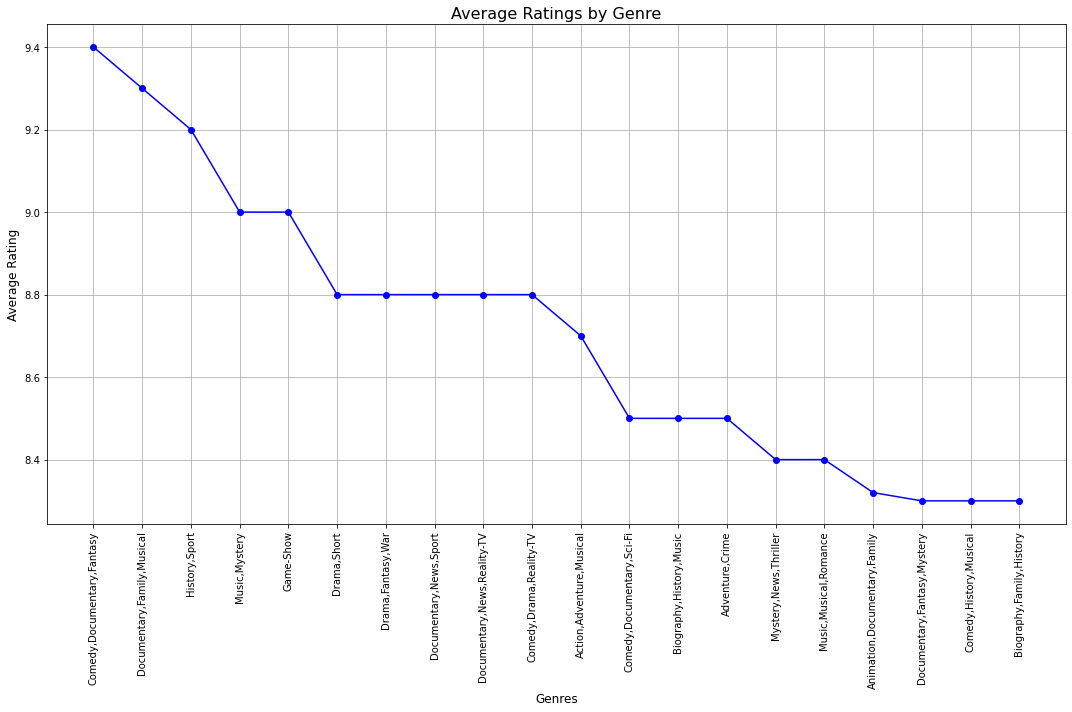

In [21]:
# Create the line graph
plt.figure(figsize=(15, 10))
plt.plot(genres, rating, marker='o', linestyle='-', color='b')

# Add labels and title
plt.title('Average Ratings by Genre', fontsize=16)
plt.xlabel('Genres', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

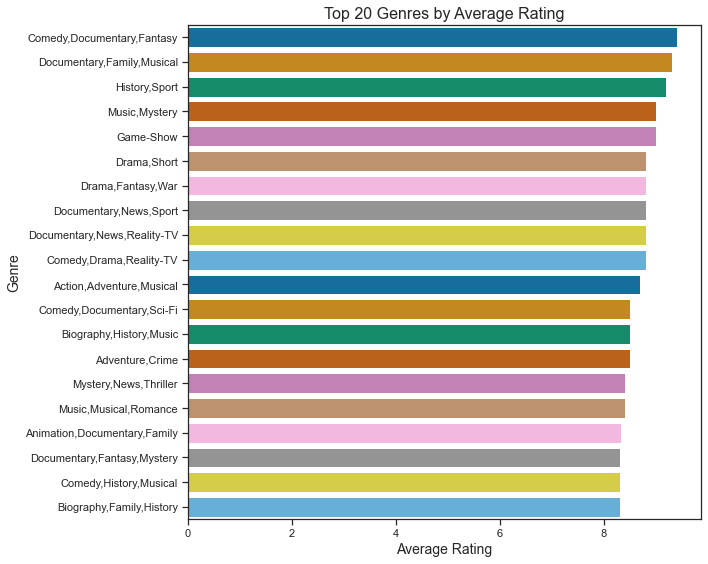

In [22]:
sns.set(style="ticks")
plt.figure(figsize=(10, 8))
sns.barplot(x='avg_rating', y='genres', data=genre_df, palette='colorblind')
plt.title('Top 20 Genres by Average Rating', fontsize=16)
plt.xlabel('Average Rating', fontsize=14)
plt.ylabel('Genre', fontsize=14)
plt.tight_layout()
plt.show()

#### Findings on  genre that is most popular among viewers based on ratings
Genres like Documentary often have higher average ratings due to strong  niche audiences while Genres like thriler  may sometimes have lower average ratings, possibly due to critical reception. 

#### Best time to release a movie to maximize viewership and revenue

In [23]:
tmdb_df['release_date'] = pd.to_datetime(tmdb_df['release_date'])

# Map month numbers to month names using lambda
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

tmdb_df['month'] = tmdb_df['release_date'].dt.month.map(lambda x: month_map[x])

tmdb_df[['release_date', 'popularity', 'month']]

,release_date,popularity,month
0,2010-11-19,33.533,Nov
1,2010-03-26,28.734,Mar
2,2010-05-07,28.515,May
3,1995-11-22,28.005,Nov
4,2010-07-16,27.920,Jul
...,...,...,...
26512,2018-10-13,0.600,Oct
26513,2018-05-01,0.600,May
26514,2018-10-01,0.600,Oct
26515,2018-06-22,0.600,Jun


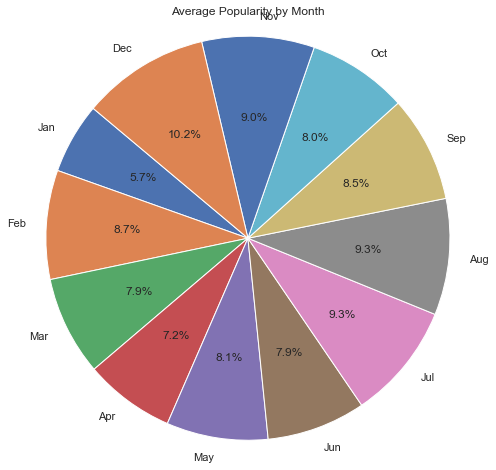

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by 'month' and calculate average popularity
monthly_avg = tmdb_df.groupby('month')['popularity'].mean()

# Sort months in calendar order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg = monthly_avg.reindex(month_order)

# Drop any months that might be NaN (if some months are missing)
monthly_avg = monthly_avg.dropna()


# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(monthly_avg, labels=monthly_avg.index, autopct='%1.1f%%', startangle=140)
plt.title('Average Popularity by Month')
plt.axis('equal')  # Equal aspect ratio ensures pie is circular
plt.show()

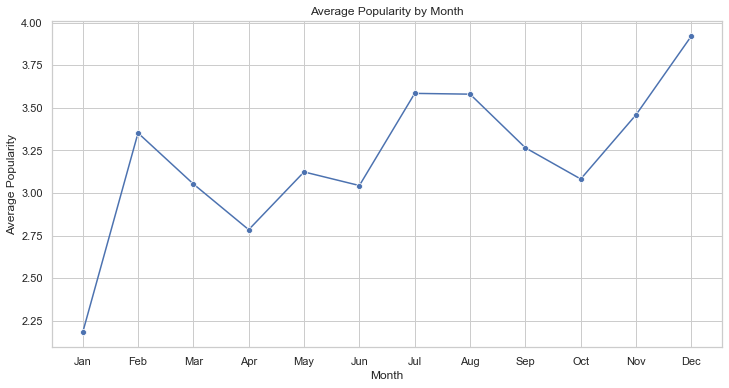

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'month' column exists — if not already extracted:
# df['month'] = pd.to_datetime(df['release_date']).dt.strftime('%b')

# Group and average
monthly_avg = tmdb_df.groupby('month')['popularity'].mean()

# Reorder months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg = monthly_avg.reindex(month_order).dropna()

# Reset index so it can be plotted with seaborn
monthly_avg_df = monthly_avg.reset_index()
monthly_avg_df.columns = ['month', 'avg_popularity']

# Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_avg_df, x='month', y='avg_popularity', marker='o')
plt.title('Average Popularity by Month')
plt.xlabel('Month')
plt.ylabel('Average Popularity')
plt.show()


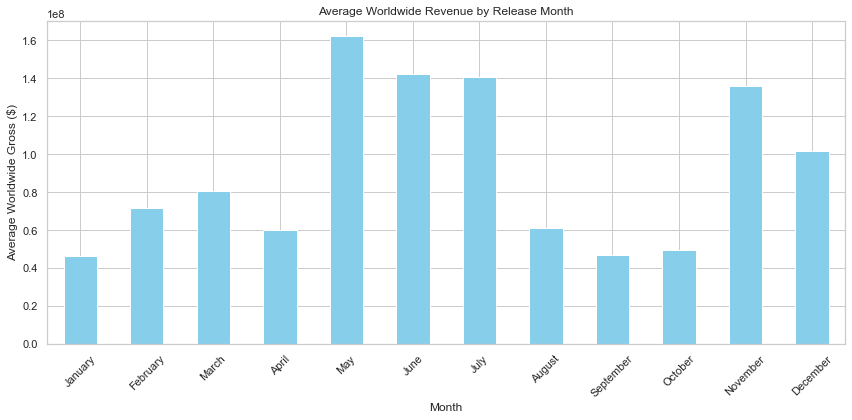

In [26]:
tn_movie_df['release_date'] = pd.to_datetime(tn_movie_df['release_date'])
tn_movie_df['month'] = tn_movie_df['release_date'].dt.month_name()

# Clean and convert 'worldwide_gross' column to numeric
tn_movie_df['worldwide_gross'] = tn_movie_df['worldwide_gross'].replace('[\$,]', '', regex=True).astype(float)

# Group by month and calculate average worldwide gross
monthly_avg = tn_movie_df.groupby('month')['worldwide_gross'].mean().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

# Plotting
plt.figure(figsize=(12, 6))
monthly_avg.plot(kind='bar', color='skyblue')
plt.title('Average Worldwide Revenue by Release Month')
plt.xlabel('Month')
plt.ylabel('Average Worldwide Gross ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Findings on the time to release a movie to maximize viewership and revenue
December is the peak time to release movies which corresponds with holiday seasons when audiences have more free time.August and July its a seasonal trend due to summer which also has a high peak.Revenue tends to align with school holidays and festive periods.
January  often show lower averages due to fewer major releases and post-holiday

## Budget range yields with the highest return on investment (ROI)


In [27]:
tn_movie_df['ROI'] = (tn_movie_df['worldwide_gross'] - tn_movie_df['production_budget']) / tn_movie_df['production_budget']
tn_movie_df

,id,release_date,title,production_budget,domestic_gross,worldwide_gross,profit_gross,month,ROI
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,2.351345e+09,December,5.532577
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,6.350639e+08,May,1.546673
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,-2.002376e+08,June,-0.572108
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1.072414e+09,May,3.243841
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,9.997217e+08,December,3.153696
...,...,...,...,...,...,...,...,...,...
5777,78,2018-12-31,Red 11,7000.0,0.0,0.000000e+00,-7.000000e+03,December,-1.000000
5778,79,1999-04-02,Following,6000.0,48482.0,2.404950e+05,2.344950e+05,April,39.082500
5779,80,2005-07-13,Return to the Land of Wonders,5000.0,1338.0,1.338000e+03,-3.662000e+03,July,-0.732400
5780,81,2015-09-29,A Plague So Pleasant,1400.0,0.0,0.000000e+00,-1.400000e+03,September,-1.000000


In [28]:
# Convert release_date to datetime format
tn_movie_df['release_date'] = pd.to_datetime(tn_movie_df['release_date'], errors='coerce')

# Extract year into a new column
tn_movie_df['release_year'] = tn_movie_df['release_date'].dt.year

# Preview the result
tn_movie_df

,id,release_date,title,production_budget,domestic_gross,worldwide_gross,profit_gross,month,ROI,release_year
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,2.351345e+09,December,5.532577,2009
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,6.350639e+08,May,1.546673,2011
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,-2.002376e+08,June,-0.572108,2019
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1.072414e+09,May,3.243841,2015
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,9.997217e+08,December,3.153696,2017
...,...,...,...,...,...,...,...,...,...,...
5777,78,2018-12-31,Red 11,7000.0,0.0,0.000000e+00,-7.000000e+03,December,-1.000000,2018
5778,79,1999-04-02,Following,6000.0,48482.0,2.404950e+05,2.344950e+05,April,39.082500,1999
5779,80,2005-07-13,Return to the Land of Wonders,5000.0,1338.0,1.338000e+03,-3.662000e+03,July,-0.732400,2005
5780,81,2015-09-29,A Plague So Pleasant,1400.0,0.0,0.000000e+00,-1.400000e+03,September,-1.000000,2015


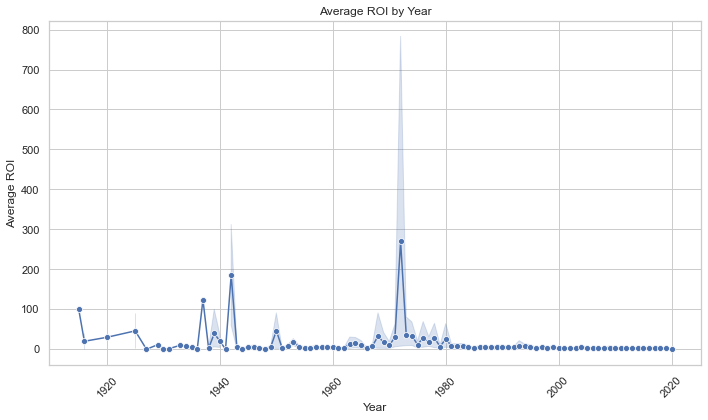

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
plt.figure(figsize=(10, 6))
sns.lineplot(data=tn_movie_df, x='release_year', y='ROI', marker='o')
plt.title('Average ROI by Year')
plt.xlabel('Year')
plt.ylabel('Average ROI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
budget_bins = [0, 1e6, 10e6, 50e6, 100e6, 200e6, 500e6]
budget_labels = ['<1M', '1M-10M', '10M-50M', '50M-100M', '100M-200M', '200M-500M']

tn_movie_df['budget_range'] = pd.cut(tn_movie_df['production_budget'], bins=budget_bins, labels=budget_labels)

In [31]:
roi_by_range = tn_movie_df.groupby('budget_range')['ROI'].mean().sort_values(ascending=False)
print(roi_by_range)

budget_range
<1M          17.637841
1M-10M        3.203034
200M-500M     2.437574
100M-200M     2.164028
10M-50M       1.865094
50M-100M      1.594578
Name: ROI, dtype: float64


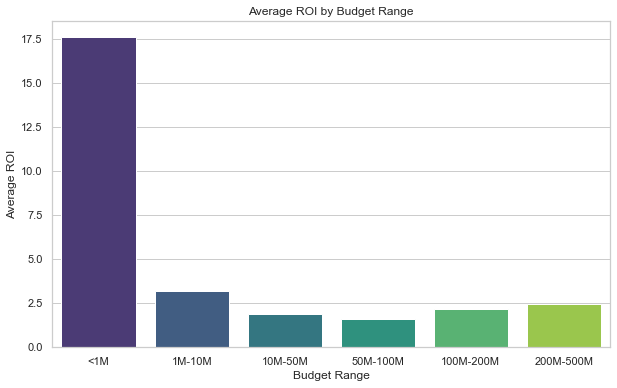

In [32]:

plt.figure(figsize=(10, 6))
sns.barplot(x=roi_by_range.index, y=roi_by_range.values, palette='viridis')
plt.title('Average ROI by Budget Range')
plt.xlabel('Budget Range')
plt.ylabel('Average ROI')
plt.show()

##### Findings on Average ROI by Budget Range
Low budget has higher average ROI, indicating that smaller budget films tend to be more profitable relative to their cost.

Higher budget ranges 200m-500m may have lower ROI, possibly because while they generate high revenue, their costs are significantly higher, reducing their ROI.


In [33]:
# Convert year to numeric if it's not already
tn_movie_df['release_year'] = pd.to_numeric(tn_movie_df['release_year'], errors='coerce')

# Create a year range (bin) column: group by 5-year periods
tn_movie_df['year_range'] = pd.cut(tn_movie_df['release_year'], 
                                   bins=range(1980, 2030, 5), 
                                   right=False,
                                   labels=[f'{y}-{y+4}' for y in range(1980, 2025, 5)])


In [34]:
roi_by_range = tn_movie_df.groupby('year_range')['ROI'].mean().reset_index()


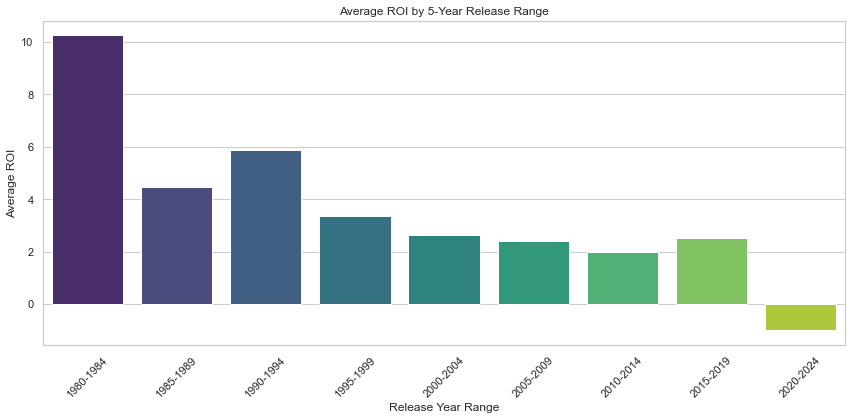

In [35]:
plt.figure(figsize=(12, 6))
sns.barplot(data=roi_by_range, x='year_range', y='ROI', palette='viridis')
plt.title('Average ROI by 5-Year Release Range')
plt.xlabel('Release Year Range')
plt.ylabel('Average ROI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### Findings on ROI on Year released
Year 1980 and 1984 had the highest average ROI

Declining ROI Periods like  2020–2024 may be due to COVID-19 pandemic’s impact on theatrical releases.


### Statistical Analysis


#### Inferential statistics On Budget range yields with the highest return on investment

In [36]:
from scipy.stats import ttest_ind
tn_movie_df['production_budget'] = tn_movie_df['production_budget'].replace('[\$,]', '', regex=True).astype(float)
high_budget =tn_movie_df[tn_movie_df['production_budget'] > 50_000_000]
low_budget = tn_movie_df[tn_movie_df['production_budget'] <= 50_000_000]

In [37]:
#Run t-test on worldwide gross
ttest_ind(high_budget['worldwide_gross'], low_budget['worldwide_gross'])



Ttest_indResult(statistic=51.977965321334324, pvalue=0.0)

### Correlation

In [38]:
#We extract the columns with numbers from the dataset of tn_movie_df

tn_numeric_df = tn_movie_df.select_dtypes(include=['number'])
tn_numeric_df

,id,production_budget,domestic_gross,worldwide_gross,profit_gross,ROI,release_year
0,1,425000000.0,760507625.0,2.776345e+09,2.351345e+09,5.532577,2009
1,2,410600000.0,241063875.0,1.045664e+09,6.350639e+08,1.546673,2011
2,3,350000000.0,42762350.0,1.497624e+08,-2.002376e+08,-0.572108,2019
3,4,330600000.0,459005868.0,1.403014e+09,1.072414e+09,3.243841,2015
4,5,317000000.0,620181382.0,1.316722e+09,9.997217e+08,3.153696,2017
...,...,...,...,...,...,...,...
5777,78,7000.0,0.0,0.000000e+00,-7.000000e+03,-1.000000,2018
5778,79,6000.0,48482.0,2.404950e+05,2.344950e+05,39.082500,1999
5779,80,5000.0,1338.0,1.338000e+03,-3.662000e+03,-0.732400,2005
5780,81,1400.0,0.0,0.000000e+00,-1.400000e+03,-1.000000,2015


In [39]:
correlation_matrix = tn_numeric_df.corr()
print(correlation_matrix)


                         id  production_budget  domestic_gross  \
id                 1.000000          -0.035278        0.008255   
production_budget -0.035278           1.000000        0.685682   
domestic_gross     0.008255           0.685682        1.000000   
worldwide_gross   -0.009422           0.748306        0.938853   
profit_gross      -0.001172           0.608752        0.926605   
ROI                0.001433          -0.048715        0.062669   
release_year      -0.011652           0.176091        0.036690   

                   worldwide_gross  profit_gross       ROI  release_year  
id                       -0.009422     -0.001172  0.001433     -0.011652  
production_budget         0.748306      0.608752 -0.048715      0.176091  
domestic_gross            0.938853      0.926605  0.062669      0.036690  
worldwide_gross           1.000000      0.981811  0.047238      0.100588  
profit_gross              0.981811      1.000000  0.070439      0.069903  
ROI                  

###### Correlation matrix provides a good overview of the linear relationships between the variables in your movie dataset.

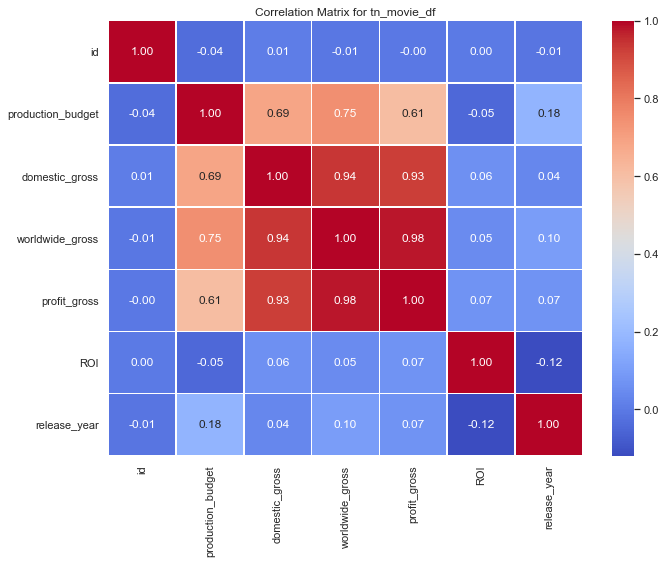

In [40]:
  plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix for tn_movie_df')
plt.tight_layout()
plt.show()

##### Interpretation

1. Worldwide Gross and Profit Gross (0.98): This is an extremely strong positive correlation. The more a movie earns globally, the higher its profit is likely to be.

2. Production Budget with Domestic Gross (0.69), Worldwide Gross (0.75), and Profit Gross (0.61): These are strong positive correlations. Generally, movies with higher production budgets tend to have higher domestic and worldwide gross earnings, leading to greater profits. However, these correlations are not perfect, indicating that budget is not the only factor determining success.

3. ROI (Return on Investment) with Production Budget (-0.05), Domestic Gross (0.06), Worldwide Gross (0.05), and Profit Gross (0.07): The correlations here are quite weak, suggesting that the initial production budget and the absolute gross/profit figures don't strongly dictate the return on investment. A smaller movie with lower gross might have a higher ROI than a blockbuster with a massive budget.

4. ROI and Release Year (-0.12): There's a slight negative correlation, suggesting a very weak tendency for ROI to potentially decrease slightly over the years in this dataset, but this relationship is not strong.


##### Summary:

- The financial variables (domestic gross, worldwide gross, and profit gross) are highly positively correlated with each other.

- Production budget has a notable positive correlation with the gross and profit variables, but it's not the sole determinant of success.

- ROI seems to be influenced by factors beyond just the absolute financial figures.



#### Linear Regression:

##### worldwide_gross from profit_gross 

We are establishing the relationship between two variables that have a strong positive correlation.


In [41]:
X = tn_movie_df['worldwide_gross']
y = tn_movie_df['profit_gross']

#Add constant for intercept
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           profit_gross   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                 1.546e+05
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        21:56:59   Log-Likelihood:            -1.0730e+05
No. Observations:                5782   AIC:                         2.146e+05
Df Residuals:                    5780   BIC:                         2.146e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            -1.52e+07   4.12e+05    -

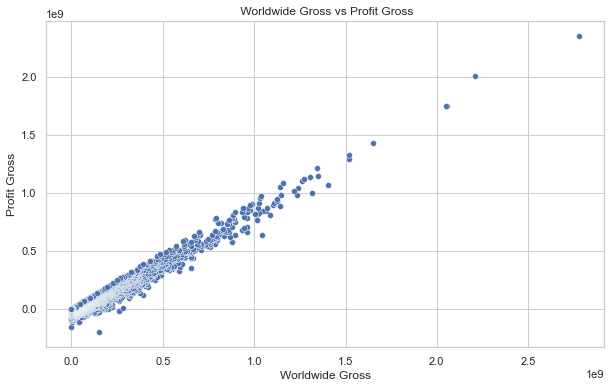

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='worldwide_gross', y='profit_gross', data=tn_movie_df)
plt.title(' Worldwide Gross vs Profit Gross')
plt.xlabel('Worldwide Gross')
plt.ylabel('Profit Gross')
plt.show()

##### Findings
This scatter plot effectively illustrates how a film's global gross revenue and profit gross have a very strong and essentially linear relationship. Increasing earnings at the worldwide box office nearly always results in increased profits. Even though there may be a small hint of growing profit fluctuation at higher gross levels, the general trend is overwhelmingly positive and steady.

##### Creating a Line of Best fit

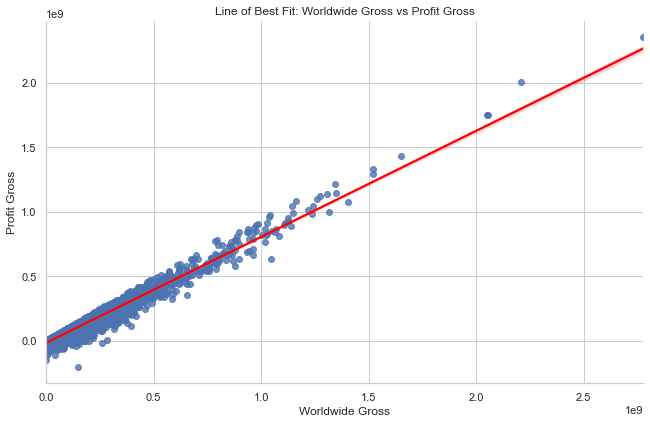

In [43]:
sns.lmplot(data=tn_movie_df, x='worldwide_gross', y='profit_gross', height=6, aspect=1.5, line_kws={"color": "red"}   )

plt.title('Line of Best Fit: Worldwide Gross vs Profit Gross')
plt.xlabel('Worldwide Gross')
plt.ylabel('Profit Gross')
plt.show()

#### Plotting Residuals

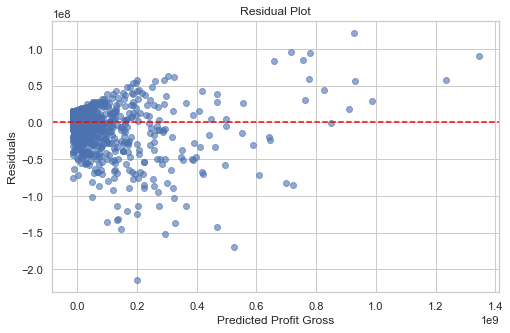

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


X = tn_movie_df[['worldwide_gross']]
y = tn_movie_df['profit_gross']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
residuals = y_test - predictions

plt.figure(figsize=(8, 5))
plt.scatter(predictions, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Profit Gross')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

##### Plotting Histogram of Residuals

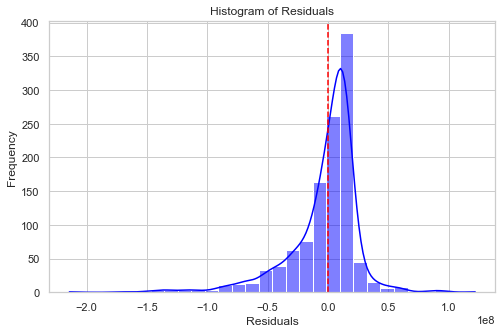

In [45]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30, color='blue')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

##### Findings

The histogram of the residuals suggests that the assumption of normality of errors in your linear regression model is likely violated. The distribution is right-skewed with a peak slightly shifted from zero, and it exhibits long tails indicating outliers.

#### worldwide_gross from production_budget 

In [46]:
import statsmodels.api as sm

X = tn_movie_df['production_budget']
y = tn_movie_df['worldwide_gross']

#Add constant for intercept
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        worldwide_gross   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     7355.
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        21:57:07   Log-Likelihood:            -1.1557e+05
No. Observations:                5782   AIC:                         2.311e+05
Df Residuals:                    5780   BIC:                         2.311e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -7.286e+06   1.91e+0

Globally, films with higher production expenditures typically make a lot more money. In actuality, studios can anticipate receiving an average of $3.13 for every dollar invested on the production. Nonetheless, the gross profits distribution is skewed, indicating that a select few films—likely blockbusters—earn disproportionately large sums of money.

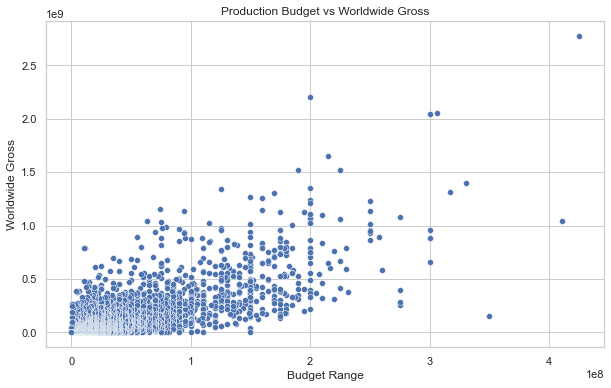

In [47]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='production_budget', y='worldwide_gross', data=tn_movie_df)
plt.title('Production Budget vs Worldwide Gross')
plt.xlabel('Budget Range')
plt.ylabel('Worldwide Gross')
plt.show()

##### Interpretation

There is a positive trend that is a general upward trend visible in the plot. As the production budget tends to increase, the worldwide gross revenue also tends to increase. This aligns with the correlation matrix you shared earlier, which showed a positive correlation (around 0.75) between these two variables

A large number of movies have production budgets below as  100 million. Within this lower budget range, the worldwide gross varies considerably, from very low to over  1 billion.

##### Conclusion
From our scatter plot it confirms a positive relationship between production budget and worldwide gross, suggesting that investing more in a movie can increase its potential to earn more globally. However, the substantial scatter highlights that budget is not the only factor determining a movie's worldwide success. Other elements like marketing, story appeal, cast, release timing, and competition play significant roles. The plot also shows a concentration of movies at lower budget levels with a wide range of outcomes, and the presence of high-budget, high-grossing blockbusters as well as some high-budget films that didn't reach the same level of global success.

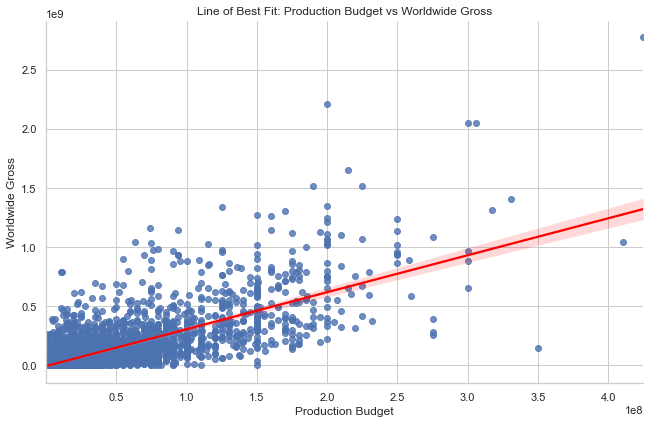

In [48]:
sns.lmplot(data=tn_movie_df, x='production_budget', y='worldwide_gross', height=6, aspect=1.5, line_kws={"color": "red"}   )

plt.title('Line of Best Fit: Production Budget vs Worldwide Gross')
plt.xlabel('Production Budget')
plt.ylabel('Worldwide Gross')
plt.show()

##### Findings

The line of best fit confirms a positive linear relationship between production budget and worldwide gross. However, the scatter of the data points around the line and the confidence interval highlight that this relationship is not deterministic, and other factors play a significant role in a movie's global box office success. The widening confidence interval at higher budgets suggests that predictions for very expensive films might be less precise.

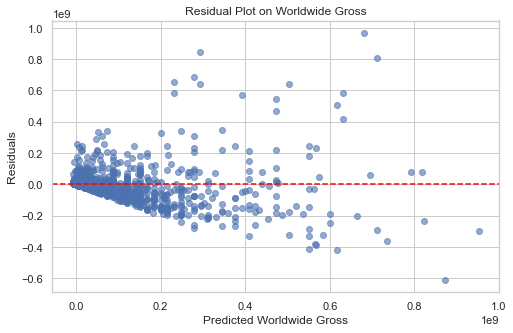

In [49]:
X = tn_movie_df[['production_budget']]
y = tn_movie_df['worldwide_gross']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
residuals = y_test - predictions

plt.figure(figsize=(8, 5))
plt.scatter(predictions, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Worldwide Gross')
plt.ylabel('Residuals')
plt.title('Residual Plot on Worldwide Gross')
plt.show()

###### Interpretation

The residuals tend to be more positive in the middle range of predicted values and then become more spread out (both positive and negative) at the higher end. This suggests that a simple linear model might not be fully capturing the relationship between production budget and worldwide gross, and there might be a non-linear component.

# Hypothesis Testing

Hypothesis testing is one of statistical measures used to study relationship between variables.

We had to identify our rersearch questions from the objectives which will enable us achieve this test.

For this case we were interested in the relationship between return on investment (ROI)and production budget.

We want to determine if there's a statistically significant linear relationship between how much money is spent on producing a movie (Production Budget) and the return it generates relative to that investment (ROI).

In [50]:
tn_movie_df['worldwide_gross'] = pd.to_numeric(tn_movie_df['worldwide_gross'], errors='coerce')
tn_movie_df['production_budget'] = pd.to_numeric(tn_movie_df['production_budget'], errors='coerce')


In [51]:
tn_movie_df['ROI'] = (tn_movie_df['worldwide_gross'] - tn_movie_df['production_budget']) / tn_movie_df['production_budget']
tn_movie_df

,id,release_date,title,production_budget,domestic_gross,worldwide_gross,profit_gross,month,ROI,release_year,budget_range,year_range
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,2.351345e+09,December,5.532577,2009,200M-500M,2005-2009
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,6.350639e+08,May,1.546673,2011,200M-500M,2010-2014
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,-2.002376e+08,June,-0.572108,2019,200M-500M,2015-2019
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1.072414e+09,May,3.243841,2015,200M-500M,2015-2019
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,9.997217e+08,December,3.153696,2017,200M-500M,2015-2019
...,...,...,...,...,...,...,...,...,...,...,...,...
5777,78,2018-12-31,Red 11,7000.0,0.0,0.000000e+00,-7.000000e+03,December,-1.000000,2018,<1M,2015-2019
5778,79,1999-04-02,Following,6000.0,48482.0,2.404950e+05,2.344950e+05,April,39.082500,1999,<1M,1995-1999
5779,80,2005-07-13,Return to the Land of Wonders,5000.0,1338.0,1.338000e+03,-3.662000e+03,July,-0.732400,2005,<1M,2005-2009
5780,81,2015-09-29,A Plague So Pleasant,1400.0,0.0,0.000000e+00,-1.400000e+03,September,-1.000000,2015,<1M,2015-2019


### Hypothesis statement
Let 
𝜇
1
be the mean ROI of high-budget movies, and 
𝜇
2

be the mean ROI of low-budget movies.

Null Hypothesis (H₀):
𝜇
1
=
𝜇
2
There is no difference in mean ROI.
This is to indicate there is no linear relationship between Production Budget and ROI in the population of movies. Any relationship observed in your sample is due to random chance.

Alternative Hypothesis (H₁):
𝜇
1
≠
𝜇
2
There is a significant difference in mean ROI.
For this, there is a linear relationship between Production Budget and ROI in the population of movies. The relationship observed in your sample is not just due to random chance.

This is a two-tailed test.

Level of alpha = 0.05

### Perform the test statistics

In [52]:
from scipy.stats import ttest_ind

# Define high and low budget threshold (e.g., median)
threshold = tn_movie_df['production_budget'].median()
high_budget = tn_movie_df[tn_movie_df['production_budget'] >= threshold]['ROI']
low_budget = tn_movie_df[tn_movie_df['production_budget'] < threshold]['ROI']

# Perform an independent t-test
t_stat, p_value = ttest_ind(high_budget, low_budget, equal_var=False)
p_value

3.555173979078268e-08

In [53]:
print("High Budget Mean ROI:", high_budget.mean())
print("Low Budget Mean ROI:", low_budget.mean())
print("p-value:", p_value)


High Budget Mean ROI: 1.6595916903497503
Low Budget Mean ROI: 5.978075243533361
p-value: 3.555173979078268e-08


### Decision rule



You compare the p-value to your chosen significance level (α):

If p-value ≤ α: You reject the null hypothesis (H 
0
​
 ). This means there is statistically significant evidence to suggest that there is a linear relationship between Production Budget and ROI in the population of movies.


If p-value > α: You fail to reject the null hypothesis (H 
0
​
 ). This means there is not enough statistical evidence from your sample to conclude that a linear relationship exists between Production Budget and ROI in the population. It doesn't necessarily mean there's no relationship, just that you haven't found statistically significant evidence of one with your data.


### Conclusion

From the p-value 
3.555173979078268e-08
<
0.05  Therefore we reject H₀

Hence come into conclusion that there is a statistically significant difference in mean ROI between high- and low-budget movies.

We performed an independent samples t-test  after categorizing movies into "high-budget" and "low-budget" groups:

The test  compared the mean ROI of the two groups, and the significant p-value indicates that the observed difference in means is unlikely to have occurred by random chance.

# Recommendations:


1. To boost audience reception and critic approval, Studio9 should consider producing genre-blending films, especially those incorporating comedy, documentary, and musical elements.

2. Releasing films in December or mid-year could enhance visibility and audience engagement, while early-year months may be less strategic for major releases.

3. For the best revenue, release films in May to July or November.  Avoid January, September, and October, unless aiming for niche audiences.


4. Movie studios and distributors should prioritize launching major titles during these high-performing months to maximize exposure and revenue. Additionally, further analysis could explore genre-specific trends or compare domestic vs. international performance across seasons.

# Next Steps

1. Predict movie success using machine learning.


2. Analyze which genre and budget combos perform best.


3. Study audience types to guide marketing.


4. Plan release dates based on seasonal trends.


5. Compare with top competitors to improve strategy.

# Conclusion

This project aimed to uncover key factors that influence movie performance, with a focus on optimizing release strategies for stakeholders in the film industry. After analyzing multiple datasets—ranging from production budgets and gross earnings to release dates and viewer ratings—it was found that release timing significantly impacts viewership and return on investment (ROI).

Specifically, the months of February, July, August, and December consistently showed higher viewership and box office performance, suggesting these periods are the most strategic windows for movie releases. These months likely align with major holidays, school breaks, and seasonal trends that drive more audience traffic to theaters.


